## Optional Advanced Part: Joint Point-Cloud Diffusion

In the advanced part, the objective is no longer to generate isolated points independently. Instead, the goal is to generate different realizations of a common shape template, where each training example consists of a full 2D point cloud. The provided dataset contains 1024 samples, and each sample contains 1024 points.

A key difference from the mandatory 2D task is that the denoising model should use information from the entire point cloud when estimating noise. Therefore, instead of predicting noise for each point independently, I use a permutation-aware model that combines local point features with permutation-invariant global features obtained by pooling across all points.

# AI Usage Statement. 
During the preparation of this work, I used ChatGPT to help organize the notebook structure, suggest code scaffolding for the mandatory and advanced parts, and improve the wording of the report sections.

The AI tool was used only as writing and planning assistance; all core ideas, code implementation, debugging, training runs, figure generation, and interpretation of results were completed and checked by me.

I carefully reviewed and revised all AI-generated suggestions and take full responsibility for the final content of this submission.

### 1. Setup

In this section, I import the required libraries, define common plotting utilities, and fix the main hyperparameters used throughout the notebook. I also select the computation device and set the random seed to improve reproducibility. Keeping the configuration in one place makes it easier to compare multiple experiments consistently.

In [1]:
# Optional Advanced Part: imports and basic helpers

import os
import math
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

set_seed(42)
ensure_dir("outputs")
ensure_dir("outputs/advanced")

Device: cpu


In [2]:
# Plotting helpers

def plot_pointcloud(pc, title="Point cloud", save_path=None):
    if isinstance(pc, torch.Tensor):
        pc = pc.detach().cpu().numpy()
    plt.figure(figsize=(5, 5))
    plt.scatter(pc[:, 0], pc[:, 1], s=3, alpha=0.75)
    plt.axis("equal")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220)
    plt.show()
    plt.close()

def plot_pointcloud_grid(batch_pcs, title="Generated point clouds", ncols=4, save_path=None):
    if isinstance(batch_pcs, torch.Tensor):
        batch_pcs = batch_pcs.detach().cpu().numpy()

    B = len(batch_pcs)
    nrows = int(np.ceil(B / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i in range(B):
        axes[i].scatter(batch_pcs[i, :, 0], batch_pcs[i, :, 1], s=2, alpha=0.7)
        axes[i].axis("equal")
        axes[i].axis("off")
        axes[i].set_title(f"sample {i}")

    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220)
    plt.show()
    plt.close()

def plot_loss(losses, title="Loss curve", save_path=None):
    plt.figure(figsize=(6, 4))
    plt.plot(losses, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220)
    plt.show()
    plt.close()

def plot_single_cloud_trajectory(traj, sample_idx=0, num_snapshots=6, title="Reverse trajectory", save_path=None):
    idx = np.linspace(0, len(traj) - 1, num_snapshots).astype(int)
    fig, axes = plt.subplots(1, num_snapshots, figsize=(3*num_snapshots, 3))

    for ax, i in zip(axes, idx):
        pc = traj[i][sample_idx].numpy()
        ax.scatter(pc[:, 0], pc[:, 1], s=2, alpha=0.7)
        ax.axis("equal")
        ax.axis("off")
        ax.set_title(f"step {i}")

    plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220)
    plt.show()
    plt.close()

### Data inspection

Before training the advanced model, I first inspect individual point-cloud samples from the dataset. This serves as a sanity check for the data format, coordinate scale, and overall variation between different realizations of the shape template.

In [4]:
# Dataset

class AdvancedPointCloudDataset(Dataset):
    """
    Expected .npy format: [num_samples, num_points, 2]
    """
    def __init__(self, npy_path, normalize=True):
        data = np.load(npy_path).astype(np.float32)
        assert data.ndim == 3 and data.shape[-1] == 2, "Expected data of shape [M, N, 2]"

        self.normalize = normalize
        self.raw_data = data

        self.global_mean = data.reshape(-1, 2).mean(axis=0, keepdims=True)
        self.global_std = data.reshape(-1, 2).std(axis=0, keepdims=True) + 1e-8

        if normalize:
            data = (data - self.global_mean) / self.global_std

        self.data = torch.from_numpy(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]   # [N, 2]

    def denormalize(self, x):
        if isinstance(x, torch.Tensor):
            mean = torch.tensor(self.global_mean, dtype=x.dtype, device=x.device)
            std = torch.tensor(self.global_std, dtype=x.dtype, device=x.device)
            return x * std + mean
        return x * self.global_std + self.global_mean

Dataset size: 1024
Single sample shape: torch.Size([1024, 2])


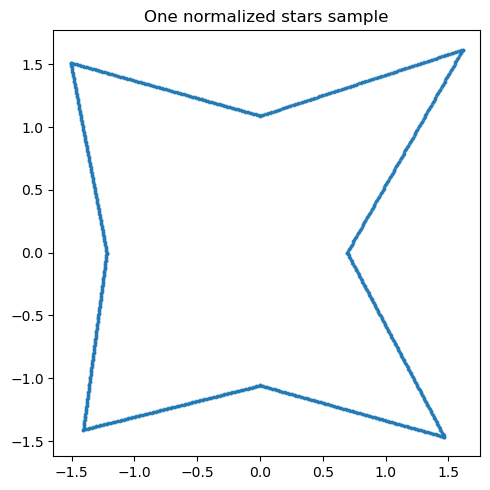

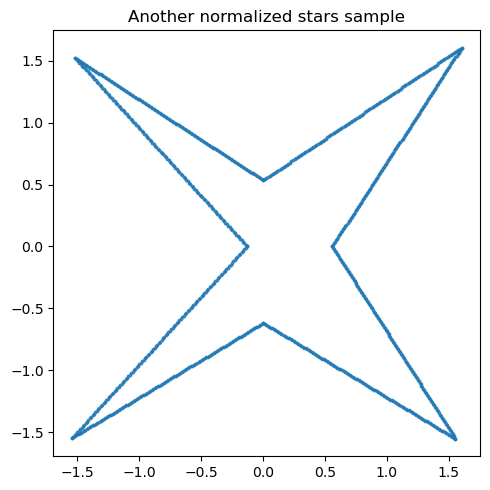

In [7]:
# Load and inspect advanced dataset

stars_ds = AdvancedPointCloudDataset("../data/Advanced/stars_data.npy", normalize=True)

print("Dataset size:", len(stars_ds))
print("Single sample shape:", stars_ds[0].shape)

plot_pointcloud(stars_ds[0], title="One normalized stars sample")
plot_pointcloud(stars_ds[10], title="Another normalized stars sample")

### Model design

The advanced denoising model processes the full noisy point cloud at once. Each point is encoded with a shared pointwise network, after which global features are extracted using permutation-invariant pooling operations. These global features are concatenated back to the local point features together with a timestep embedding, and the model predicts the noise for all points jointly.

This architecture is designed to preserve permutation consistency: if the order of the input points changes, the pooled global information remains unchanged, while the output noise predictions follow the same permutation as the input points.

In [8]:
# Sinusoidal embedding

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        if dim % 2 != 0:
            raise ValueError("Embedding dimension must be even.")
        self.dim = dim

    def forward(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(-1)

        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=x.device).float() / max(half - 1, 1)
        )
        angles = x * freqs.unsqueeze(0)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)

In [9]:
# Advanced model: local encoder + permutation-invariant global pooling + pointwise noise head

class SharedPointEncoder(nn.Module):
    def __init__(self, coord_emb_dim=64, hidden_dim=128):
        super().__init__()
        self.x_embed = SinusoidalEmbedding(coord_emb_dim)
        self.y_embed = SinusoidalEmbedding(coord_emb_dim)

        in_dim = coord_emb_dim * 2
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )

    def forward(self, points):
        """
        points: [B, N, 2]
        returns: [B, N, H]
        """
        B, N, _ = points.shape
        x = points[:, :, 0].reshape(B * N, 1)
        y = points[:, :, 1].reshape(B * N, 1)

        x_emb = self.x_embed(x)
        y_emb = self.y_embed(y)
        feat = torch.cat([x_emb, y_emb], dim=-1)
        feat = self.net(feat)
        return feat.view(B, N, -1)


class AdvancedNoisePredictor(nn.Module):
    def __init__(self, coord_emb_dim=64, time_emb_dim=64, hidden_dim=128, global_dim=128):
        super().__init__()

        self.point_encoder = SharedPointEncoder(coord_emb_dim=coord_emb_dim, hidden_dim=hidden_dim)
        self.t_embed = SinusoidalEmbedding(time_emb_dim)

        self.global_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, global_dim),
            nn.SiLU(),
            nn.Linear(global_dim, global_dim),
            nn.SiLU(),
        )

        fusion_dim = hidden_dim + global_dim + time_emb_dim
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x_t, t):
        """
        x_t: [B, N, 2]
        t:   [B]
        out: [B, N, 2]
        """
        B, N, _ = x_t.shape

        local_feat = self.point_encoder(x_t)              # [B, N, H]

        mean_pool = local_feat.mean(dim=1)                # [B, H]
        max_pool = local_feat.max(dim=1).values           # [B, H]
        global_feat = torch.cat([mean_pool, max_pool], dim=-1)
        global_feat = self.global_proj(global_feat)       # [B, G]
        global_feat = global_feat.unsqueeze(1).repeat(1, N, 1)

        t_feat = self.t_embed(t.float())                  # [B, Tdim]
        t_feat = t_feat.unsqueeze(1).repeat(1, N, 1)

        fused = torch.cat([local_feat, global_feat, t_feat], dim=-1)
        out = self.head(fused)
        return out

In [10]:
# Diffusion on full point clouds

def make_beta_schedule(T, schedule="linear", beta_start=1e-4, beta_end=2e-2):
    if schedule == "linear":
        return torch.linspace(beta_start, beta_end, T)
    elif schedule == "quadratic":
        return torch.linspace(beta_start**0.5, beta_end**0.5, T) ** 2
    elif schedule == "constant":
        return torch.full((T,), beta_end)
    else:
        raise ValueError("Unknown schedule")

class DiffusionPointCloud:
    def __init__(self, T=50, schedule="linear", beta_start=1e-4, beta_end=2e-2, device="cuda"):
        self.T = T
        self.device = device

        self.betas = make_beta_schedule(T, schedule, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)

    def q_sample(self, x0, t, noise=None):
        """
        x0: [B, N, 2]
        t:  [B]
        """
        if noise is None:
            noise = torch.randn_like(x0)

        coeff1 = self.sqrt_alpha_bars[t].view(-1, 1, 1)
        coeff2 = self.sqrt_one_minus_alpha_bars[t].view(-1, 1, 1)
        x_t = coeff1 * x0 + coeff2 * noise
        return x_t, noise

    @torch.no_grad()
    def p_sample(self, model, x_t, t):
        beta_t = self.betas[t].view(-1, 1, 1)
        alpha_t = self.alphas[t].view(-1, 1, 1)
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1)

        eps_theta = model(x_t, t)
        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_theta
        )

        if t[0].item() > 0:
            z = torch.randn_like(x_t)
            x_prev = mean + torch.sqrt(beta_t) * z
        else:
            x_prev = mean

        return x_prev

    @torch.no_grad()
    def sample(self, model, batch_size, num_points, return_trajectory=False):
        x = torch.randn(batch_size, num_points, 2, device=self.device)
        traj = [x.detach().cpu()] if return_trajectory else None

        for step in reversed(range(self.T)):
            t = torch.full((batch_size,), step, device=self.device, dtype=torch.long)
            x = self.p_sample(model, x, t)
            if return_trajectory:
                traj.append(x.detach().cpu())

        if return_trajectory:
            return x.detach().cpu(), traj
        return x.detach().cpu()

In [11]:
# Advanced config

ADV_CONFIG = {
    "T": 50,
    "schedule": "linear",
    "beta_start": 1e-4,
    "beta_end": 2e-2,
    "batch_size": 8,
    "lr": 1e-3,
    "num_steps": 15000,
    "coord_emb_dim": 64,
    "time_emb_dim": 64,
    "hidden_dim": 128,
    "global_dim": 128,
    "save_every": 1000,
    "num_preview_samples": 8,
    "seed": 42,
}

ADV_CONFIG

{'T': 50,
 'schedule': 'linear',
 'beta_start': 0.0001,
 'beta_end': 0.02,
 'batch_size': 8,
 'lr': 0.001,
 'num_steps': 15000,
 'coord_emb_dim': 64,
 'time_emb_dim': 64,
 'hidden_dim': 128,
 'global_dim': 128,
 'save_every': 1000,
 'num_preview_samples': 8,
 'seed': 42}

### Training procedure

The training objective follows the same diffusion principle as in the mandatory part. For each training batch, I sample a diffusion timestep for every point cloud, add Gaussian noise to the clean point cloud, and train the network to predict the exact noise that was used. The loss is the mean squared error between the true noise and the predicted noise.

During training, I periodically generate samples by starting from Gaussian noise and iteratively applying the learned reverse process. These intermediate samples are useful for evaluating whether the model is learning global structure instead of merely producing noisy point sets.

In [12]:
# Training function

def train_advanced(data_path, output_dir="outputs/advanced/stars", config=ADV_CONFIG, device=device):
    set_seed(config["seed"])

    ensure_dir(output_dir)
    ensure_dir(os.path.join(output_dir, "figures"))
    ensure_dir(os.path.join(output_dir, "checkpoints"))

    dataset = AdvancedPointCloudDataset(data_path, normalize=True)
    loader = DataLoader(dataset, batch_size=config["batch_size"], shuffle=True, drop_last=True)
    data_iter = iter(loader)

    num_points = dataset[0].shape[0]

    model = AdvancedNoisePredictor(
        coord_emb_dim=config["coord_emb_dim"],
        time_emb_dim=config["time_emb_dim"],
        hidden_dim=config["hidden_dim"],
        global_dim=config["global_dim"],
    ).to(device)

    diffusion = DiffusionPointCloud(
        T=config["T"],
        schedule=config["schedule"],
        beta_start=config["beta_start"],
        beta_end=config["beta_end"],
        device=device,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    losses = []

    with open(os.path.join(output_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    model.train()
    for step in range(1, config["num_steps"] + 1):
        try:
            x0 = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x0 = next(data_iter)

        x0 = x0.to(device)                       # [B, N, 2]
        B = x0.shape[0]

        t = torch.randint(0, config["T"], (B,), device=device, dtype=torch.long)
        x_t, noise = diffusion.q_sample(x0, t)
        noise_pred = model(x_t, t)

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if step % 100 == 0:
            print(f"[advanced] step {step}/{config['num_steps']} | loss = {loss.item():.6f}")

        if step % config["save_every"] == 0 or step == 1:
            model.eval()
            gen = diffusion.sample(
                model,
                batch_size=config["num_preview_samples"],
                num_points=num_points,
                return_trajectory=False,
            )

            plot_pointcloud_grid(
                gen,
                title=f"Advanced samples at step {step}",
                ncols=4,
                save_path=os.path.join(output_dir, "figures", f"samples_step_{step:06d}.png")
            )

            plot_loss(
                losses,
                title="Advanced training loss",
                save_path=os.path.join(output_dir, "figures", "loss_curve.png")
            )

            torch.save(
                {
                    "step": step,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "losses": losses,
                },
                os.path.join(output_dir, "checkpoints", f"ckpt_step_{step:06d}.pt")
            )
            model.train()

    torch.save(
        model.state_dict(),
        os.path.join(output_dir, "checkpoints", "final_model.pt")
    )

    model.eval()
    final_samples, traj = diffusion.sample(
        model,
        batch_size=config["num_preview_samples"],
        num_points=num_points,
        return_trajectory=True,
    )

    plot_pointcloud_grid(
        final_samples,
        title="Advanced final generated samples",
        ncols=4,
        save_path=os.path.join(output_dir, "figures", "final_samples.png")
    )

    plot_loss(
        losses,
        title="Advanced final loss curve",
        save_path=os.path.join(output_dir, "figures", "loss_curve_final.png")
    )

    return model, diffusion, dataset, losses, final_samples, traj

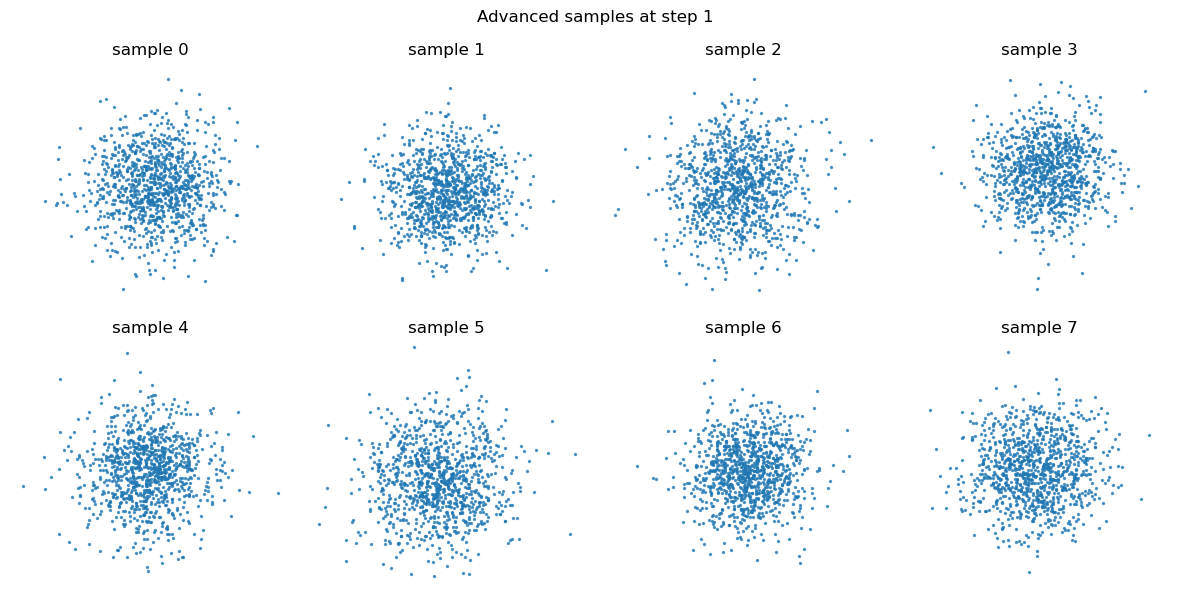

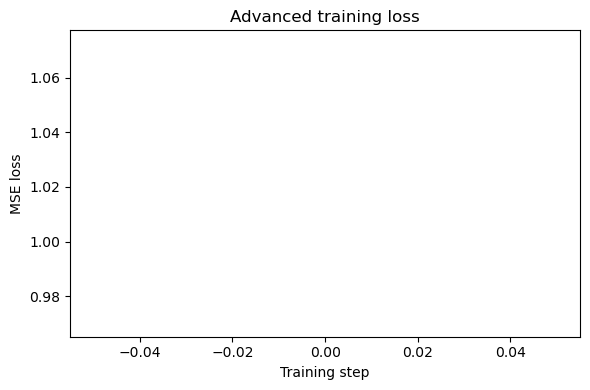

[advanced] step 100/15000 | loss = 0.758588
[advanced] step 200/15000 | loss = 0.683047
[advanced] step 300/15000 | loss = 0.740650
[advanced] step 400/15000 | loss = 0.811800
[advanced] step 500/15000 | loss = 0.747996
[advanced] step 600/15000 | loss = 0.732818
[advanced] step 700/15000 | loss = 0.746700
[advanced] step 800/15000 | loss = 0.738355
[advanced] step 900/15000 | loss = 0.701674
[advanced] step 1000/15000 | loss = 0.810579


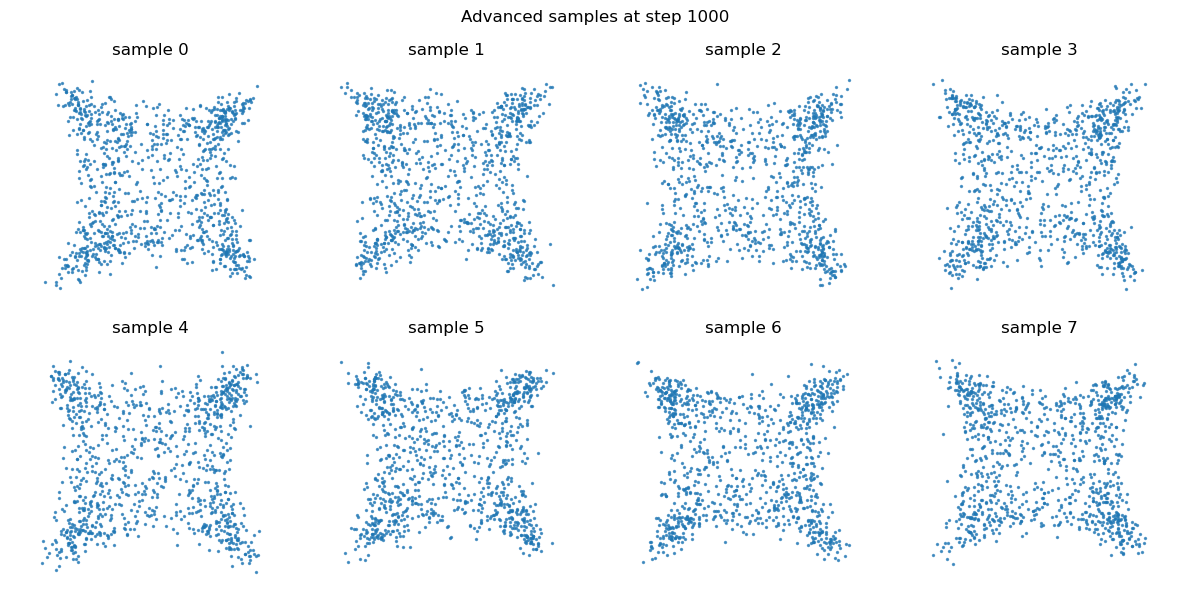

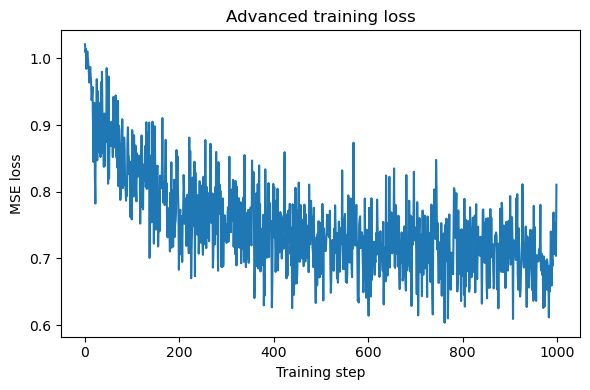

[advanced] step 1100/15000 | loss = 0.742413
[advanced] step 1200/15000 | loss = 0.653220
[advanced] step 1300/15000 | loss = 0.718557
[advanced] step 1400/15000 | loss = 0.715513
[advanced] step 1500/15000 | loss = 0.711843
[advanced] step 1600/15000 | loss = 0.697940
[advanced] step 1700/15000 | loss = 0.667251
[advanced] step 1800/15000 | loss = 0.662883
[advanced] step 1900/15000 | loss = 0.599705
[advanced] step 2000/15000 | loss = 0.626085


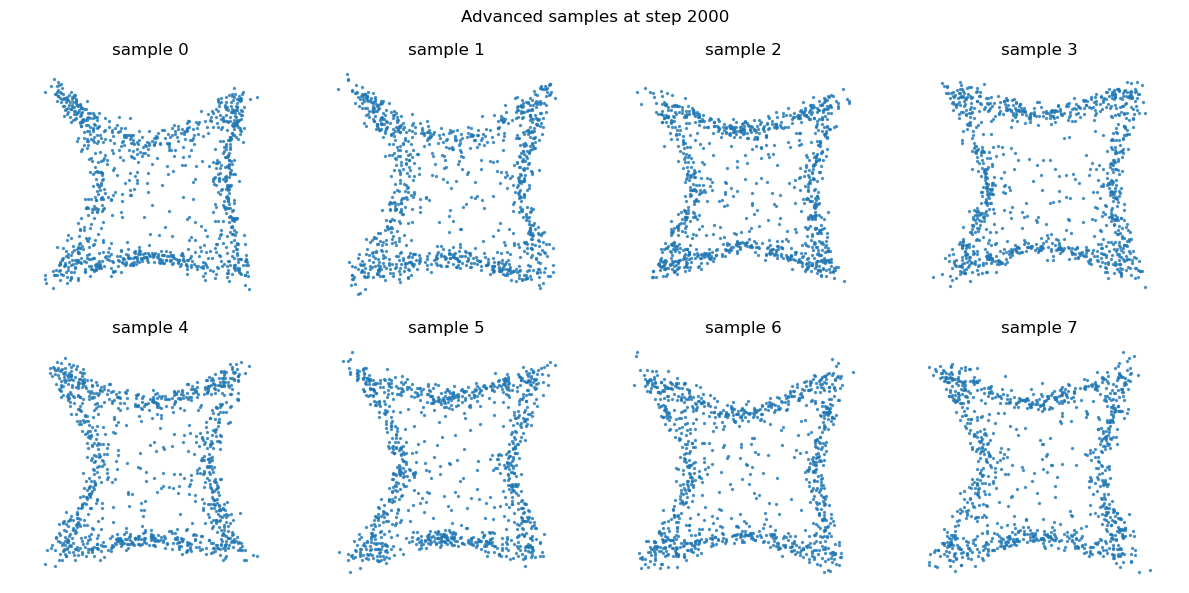

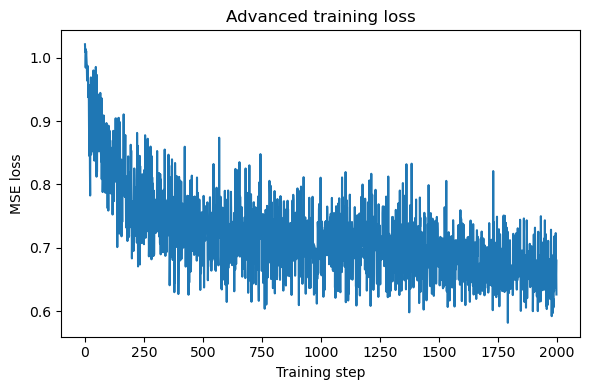

[advanced] step 2100/15000 | loss = 0.648569
[advanced] step 2200/15000 | loss = 0.603819
[advanced] step 2300/15000 | loss = 0.619642
[advanced] step 2400/15000 | loss = 0.631471
[advanced] step 2500/15000 | loss = 0.638198
[advanced] step 2600/15000 | loss = 0.638561
[advanced] step 2700/15000 | loss = 0.637439
[advanced] step 2800/15000 | loss = 0.638270
[advanced] step 2900/15000 | loss = 0.635240
[advanced] step 3000/15000 | loss = 0.639297


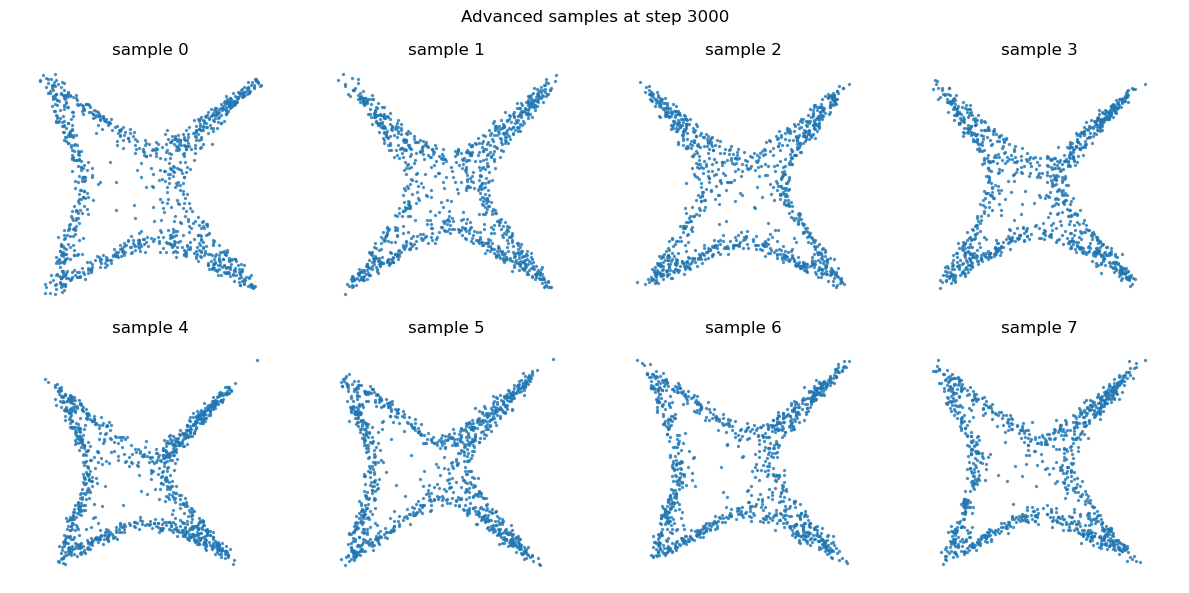

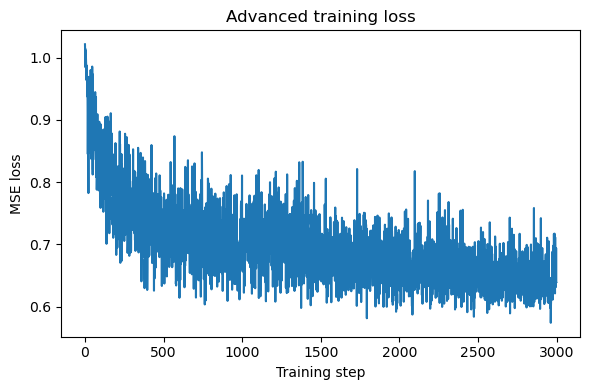

[advanced] step 3100/15000 | loss = 0.653337
[advanced] step 3200/15000 | loss = 0.596211
[advanced] step 3300/15000 | loss = 0.630585
[advanced] step 3400/15000 | loss = 0.643660
[advanced] step 3500/15000 | loss = 0.625459
[advanced] step 3600/15000 | loss = 0.619782
[advanced] step 3700/15000 | loss = 0.613742
[advanced] step 3800/15000 | loss = 0.618570
[advanced] step 3900/15000 | loss = 0.604215
[advanced] step 4000/15000 | loss = 0.734035


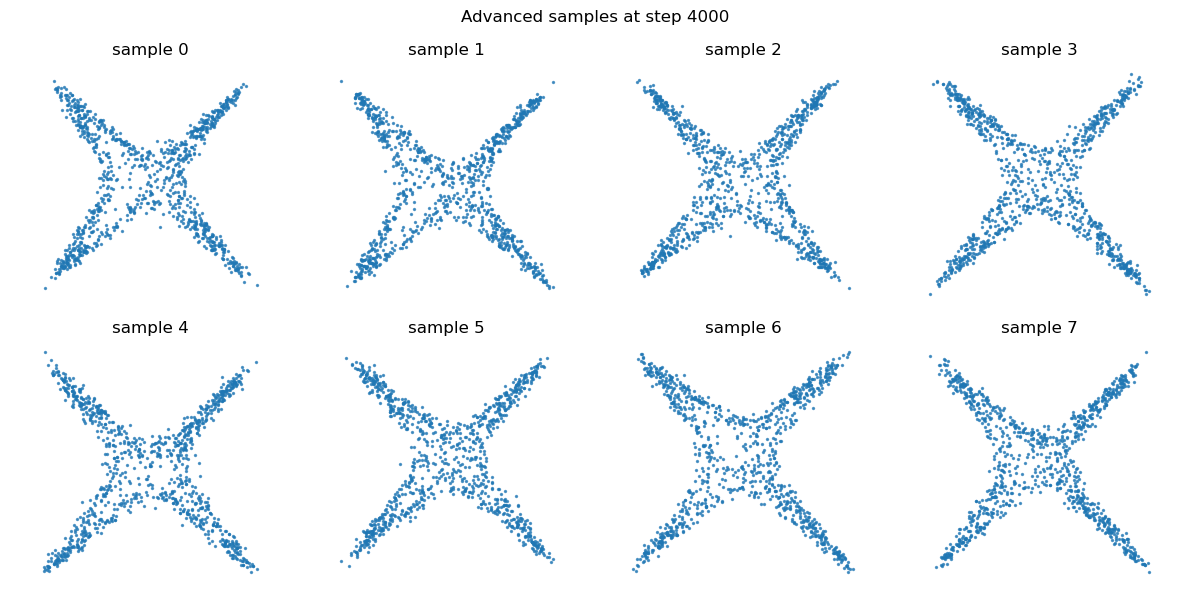

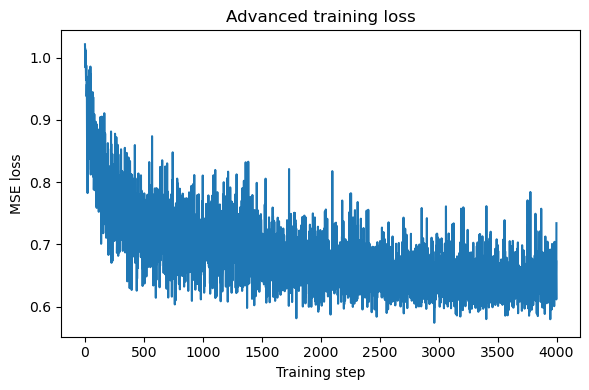

[advanced] step 4100/15000 | loss = 0.645178
[advanced] step 4200/15000 | loss = 0.701076
[advanced] step 4300/15000 | loss = 0.619696
[advanced] step 4400/15000 | loss = 0.647893
[advanced] step 4500/15000 | loss = 0.644897
[advanced] step 4600/15000 | loss = 0.624319
[advanced] step 4700/15000 | loss = 0.602820
[advanced] step 4800/15000 | loss = 0.602076
[advanced] step 4900/15000 | loss = 0.610980
[advanced] step 5000/15000 | loss = 0.608405


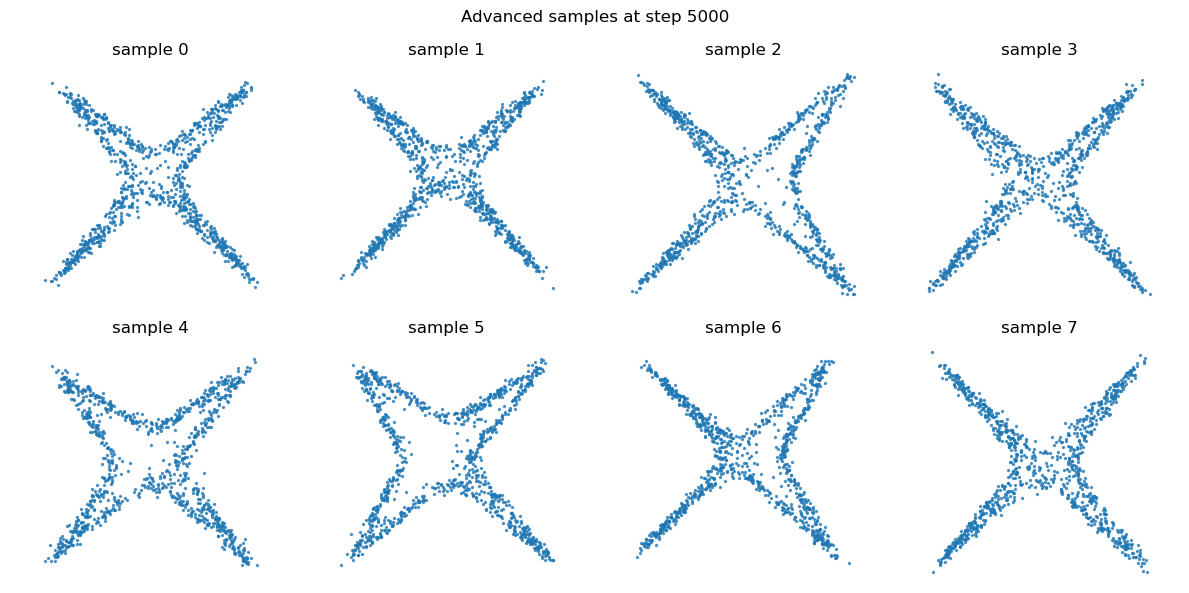

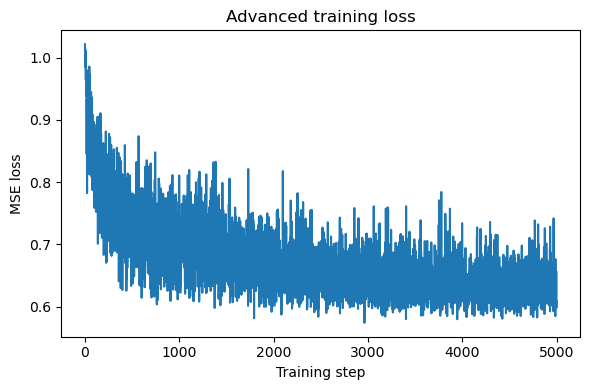

[advanced] step 5100/15000 | loss = 0.621052
[advanced] step 5200/15000 | loss = 0.679163
[advanced] step 5300/15000 | loss = 0.649818
[advanced] step 5400/15000 | loss = 0.608208
[advanced] step 5500/15000 | loss = 0.592953
[advanced] step 5600/15000 | loss = 0.640720
[advanced] step 5700/15000 | loss = 0.634433
[advanced] step 5800/15000 | loss = 0.609309
[advanced] step 5900/15000 | loss = 0.612268
[advanced] step 6000/15000 | loss = 0.640695


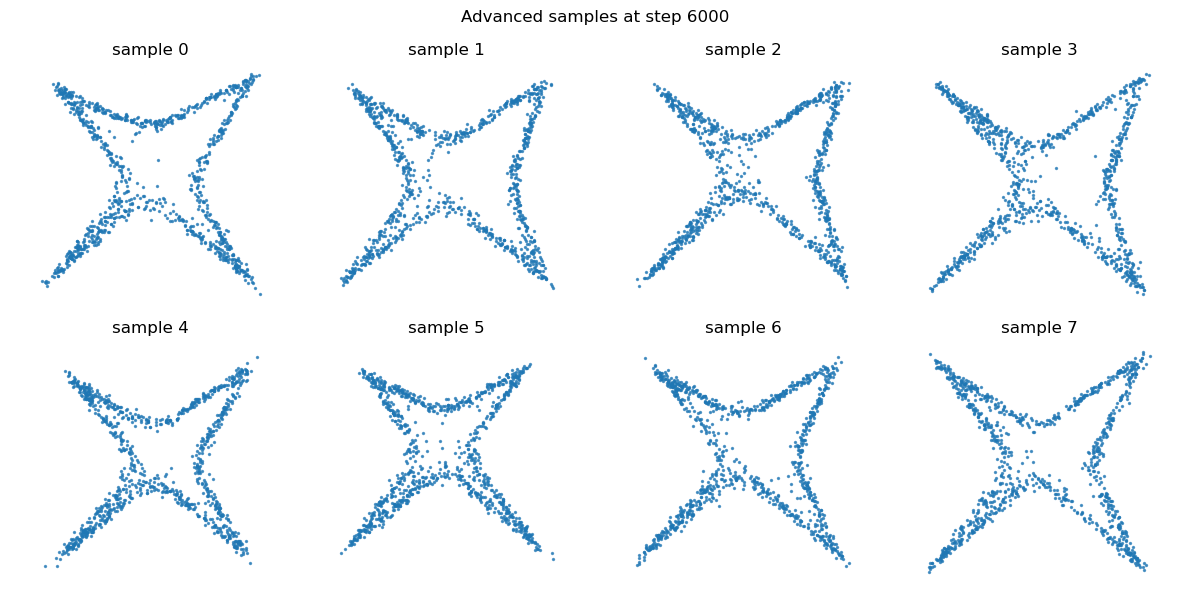

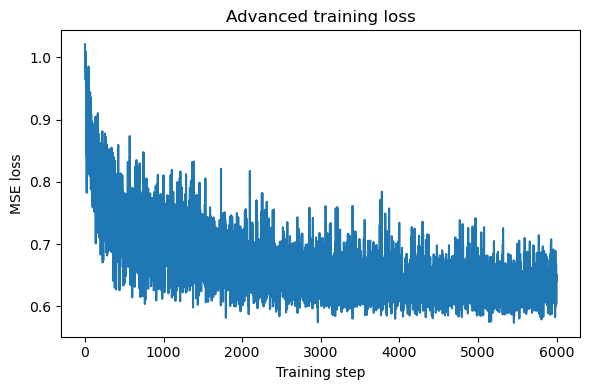

[advanced] step 6100/15000 | loss = 0.643661
[advanced] step 6200/15000 | loss = 0.634225
[advanced] step 6300/15000 | loss = 0.607564
[advanced] step 6400/15000 | loss = 0.616138
[advanced] step 6500/15000 | loss = 0.643172
[advanced] step 6600/15000 | loss = 0.629729
[advanced] step 6700/15000 | loss = 0.614437
[advanced] step 6800/15000 | loss = 0.618084
[advanced] step 6900/15000 | loss = 0.608274
[advanced] step 7000/15000 | loss = 0.618353


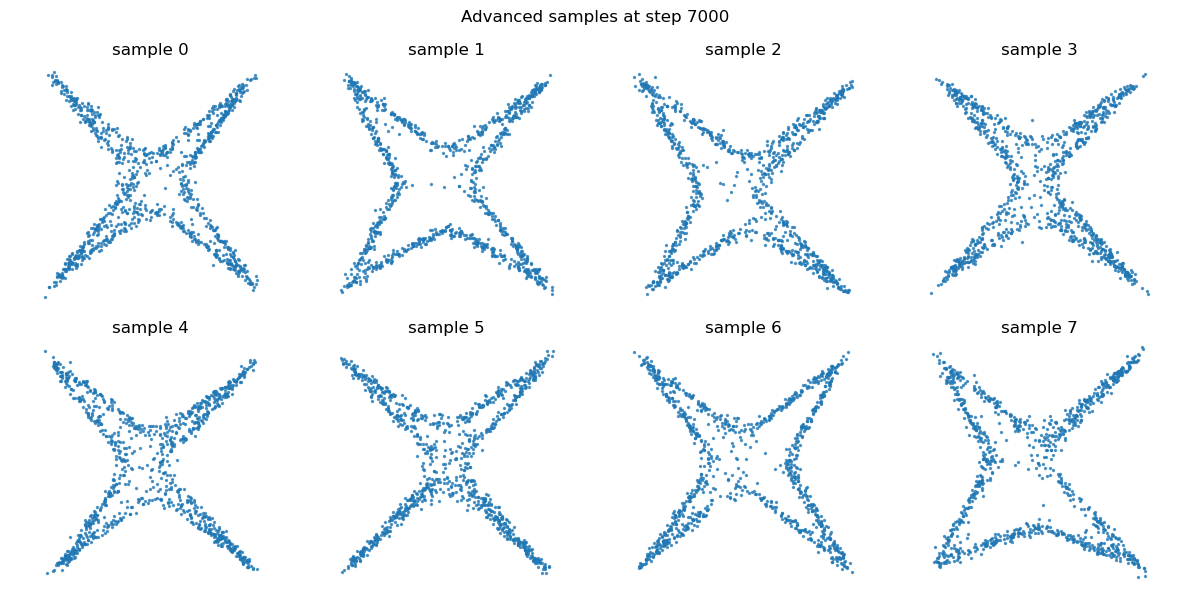

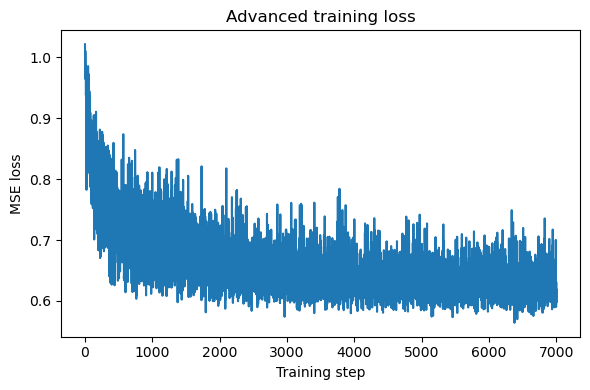

[advanced] step 7100/15000 | loss = 0.586926
[advanced] step 7200/15000 | loss = 0.605912
[advanced] step 7300/15000 | loss = 0.593383
[advanced] step 7400/15000 | loss = 0.614501
[advanced] step 7500/15000 | loss = 0.615151
[advanced] step 7600/15000 | loss = 0.646428
[advanced] step 7700/15000 | loss = 0.618947
[advanced] step 7800/15000 | loss = 0.624129
[advanced] step 7900/15000 | loss = 0.645203
[advanced] step 8000/15000 | loss = 0.586029


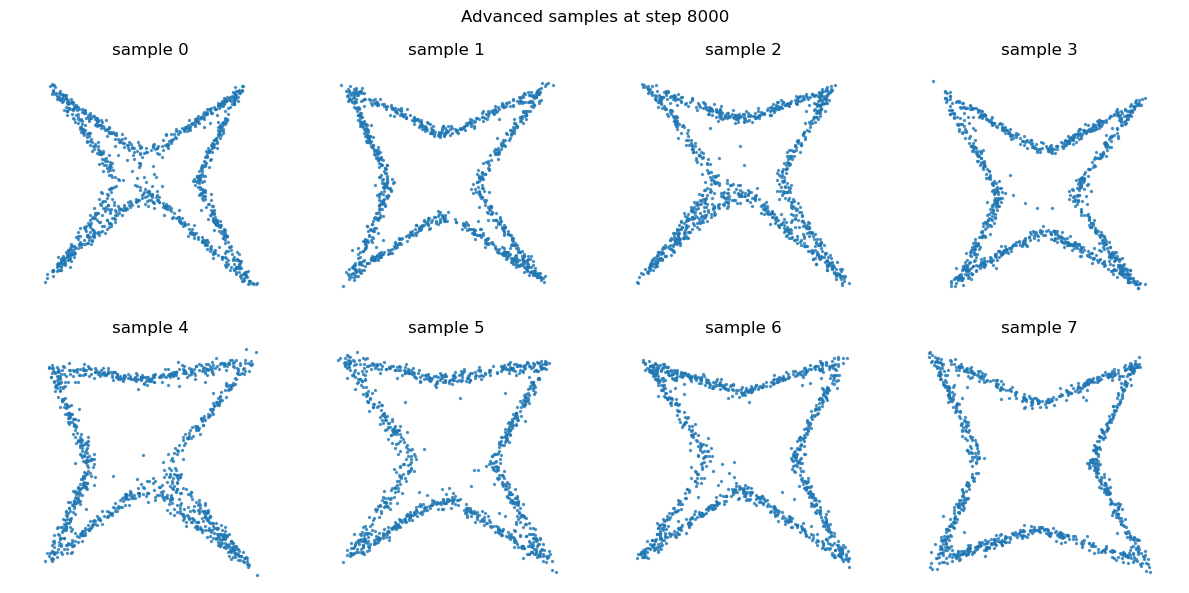

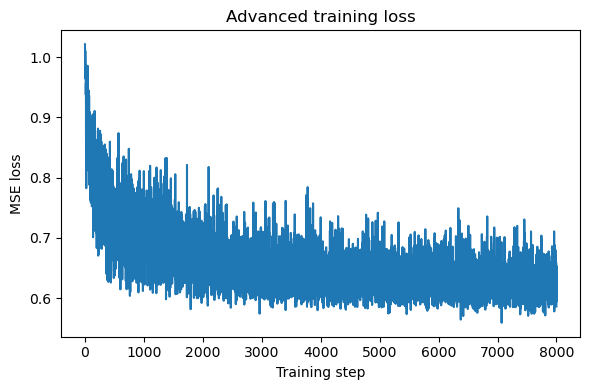

[advanced] step 8100/15000 | loss = 0.661929
[advanced] step 8200/15000 | loss = 0.642964
[advanced] step 8300/15000 | loss = 0.613233
[advanced] step 8400/15000 | loss = 0.610425
[advanced] step 8500/15000 | loss = 0.594025
[advanced] step 8600/15000 | loss = 0.639919
[advanced] step 8700/15000 | loss = 0.669122
[advanced] step 8800/15000 | loss = 0.610743
[advanced] step 8900/15000 | loss = 0.613285
[advanced] step 9000/15000 | loss = 0.619038


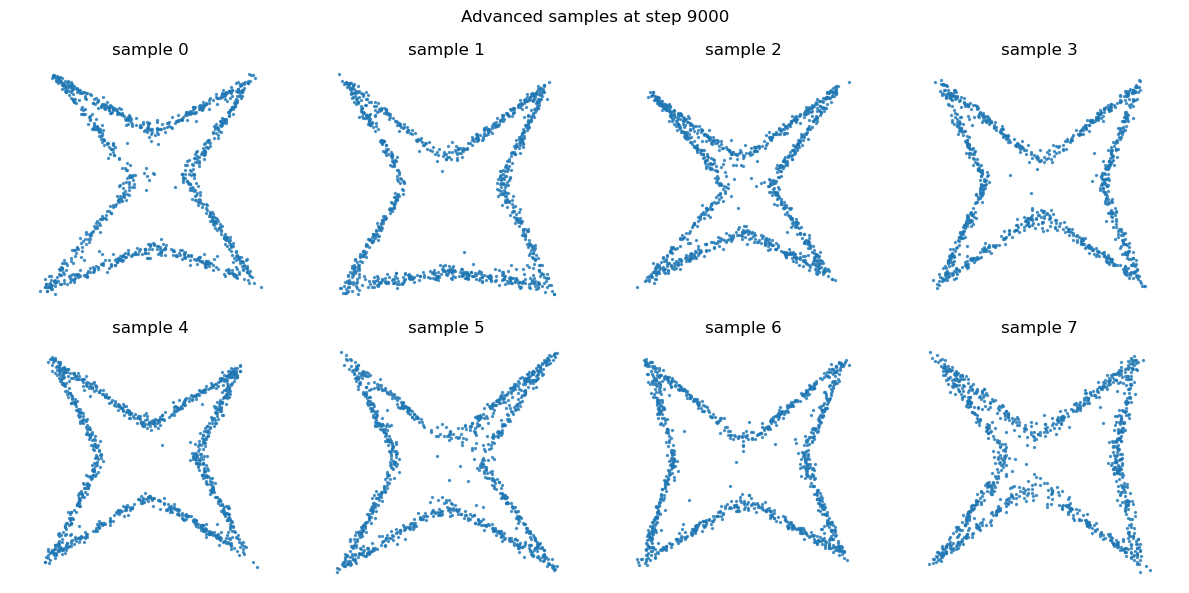

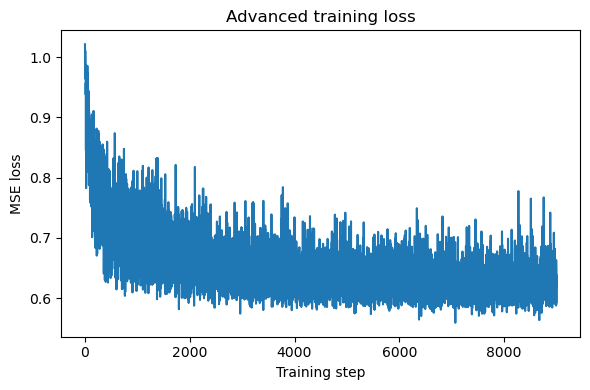

[advanced] step 9100/15000 | loss = 0.578260
[advanced] step 9200/15000 | loss = 0.614955
[advanced] step 9300/15000 | loss = 0.599533
[advanced] step 9400/15000 | loss = 0.588770
[advanced] step 9500/15000 | loss = 0.598287
[advanced] step 9600/15000 | loss = 0.593646
[advanced] step 9700/15000 | loss = 0.606673
[advanced] step 9800/15000 | loss = 0.627230
[advanced] step 9900/15000 | loss = 0.602801
[advanced] step 10000/15000 | loss = 0.611470


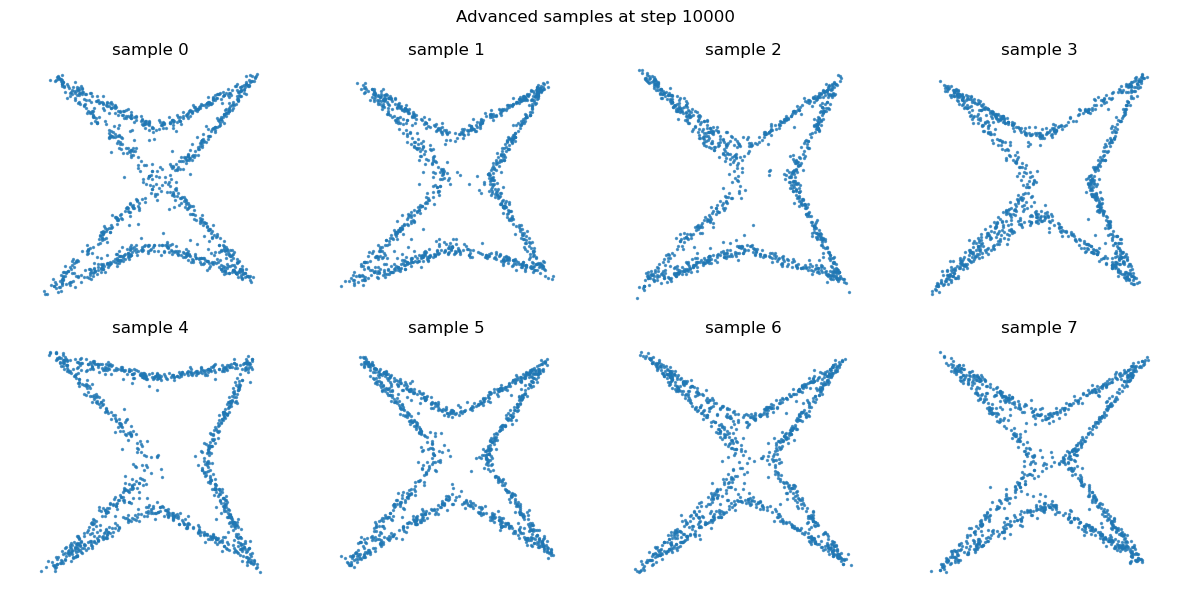

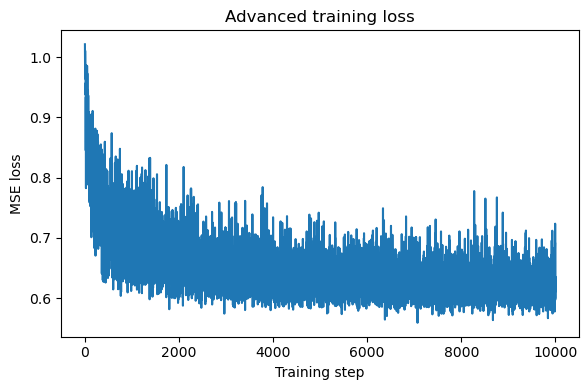

[advanced] step 10100/15000 | loss = 0.611081
[advanced] step 10200/15000 | loss = 0.627208
[advanced] step 10300/15000 | loss = 0.609830
[advanced] step 10400/15000 | loss = 0.590050
[advanced] step 10500/15000 | loss = 0.602951
[advanced] step 10600/15000 | loss = 0.607961
[advanced] step 10700/15000 | loss = 0.594391
[advanced] step 10800/15000 | loss = 0.610675
[advanced] step 10900/15000 | loss = 0.622787
[advanced] step 11000/15000 | loss = 0.652950


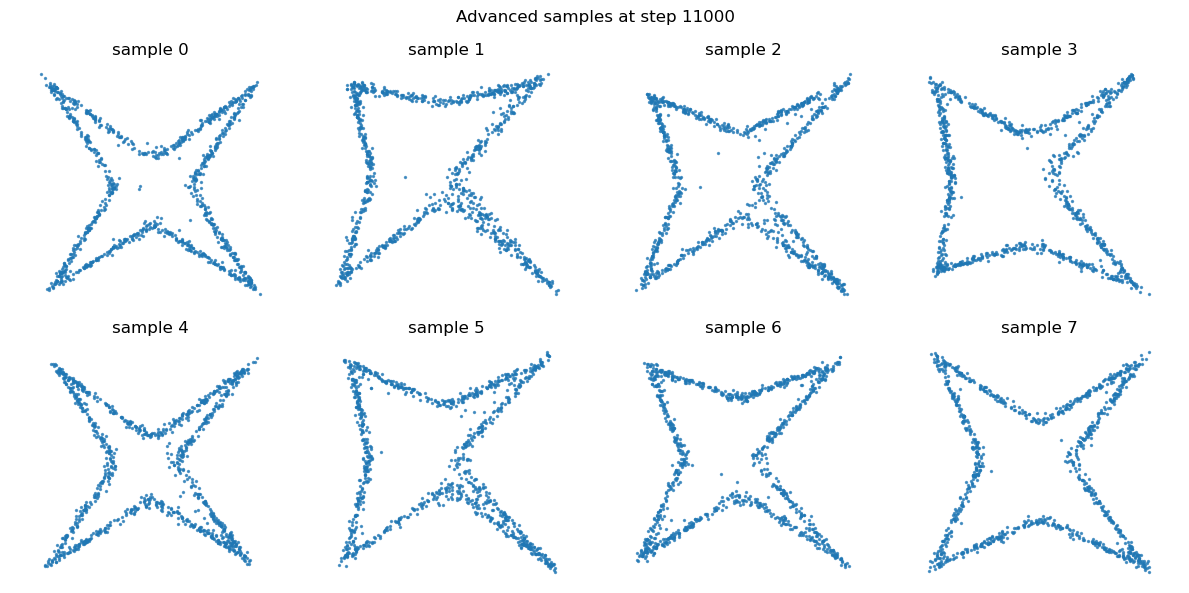

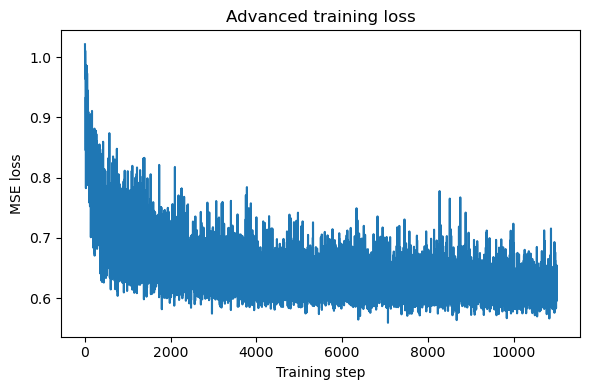

[advanced] step 11100/15000 | loss = 0.624271
[advanced] step 11200/15000 | loss = 0.607571
[advanced] step 11300/15000 | loss = 0.642028
[advanced] step 11400/15000 | loss = 0.595078
[advanced] step 11500/15000 | loss = 0.588953
[advanced] step 11600/15000 | loss = 0.605353
[advanced] step 11700/15000 | loss = 0.614572
[advanced] step 11800/15000 | loss = 0.632027
[advanced] step 11900/15000 | loss = 0.628222
[advanced] step 12000/15000 | loss = 0.616954


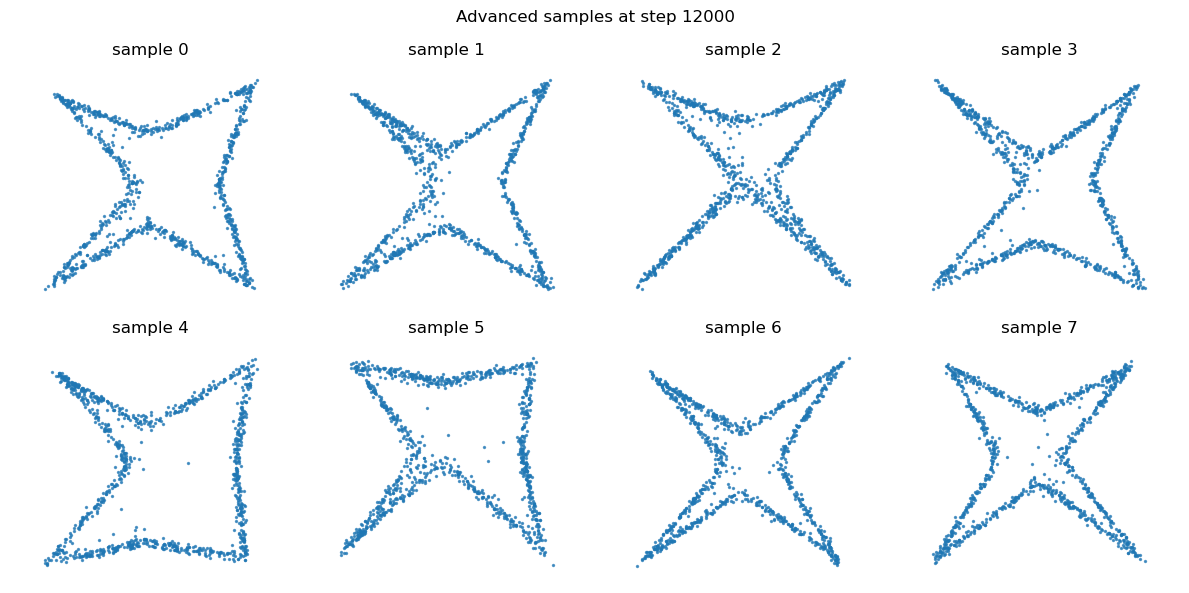

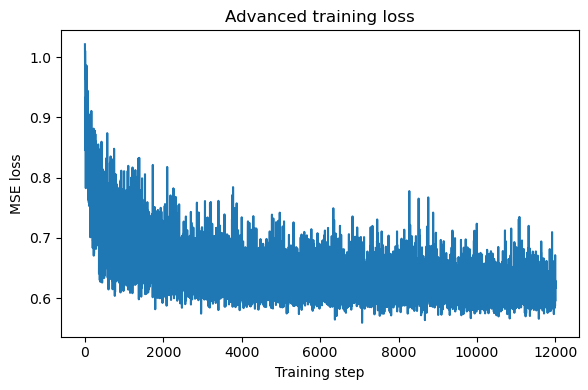

[advanced] step 12100/15000 | loss = 0.644442
[advanced] step 12200/15000 | loss = 0.632272
[advanced] step 12300/15000 | loss = 0.645205
[advanced] step 12400/15000 | loss = 0.593642
[advanced] step 12500/15000 | loss = 0.580232
[advanced] step 12600/15000 | loss = 0.693117
[advanced] step 12700/15000 | loss = 0.599360
[advanced] step 12800/15000 | loss = 0.606094
[advanced] step 12900/15000 | loss = 0.629571
[advanced] step 13000/15000 | loss = 0.610084


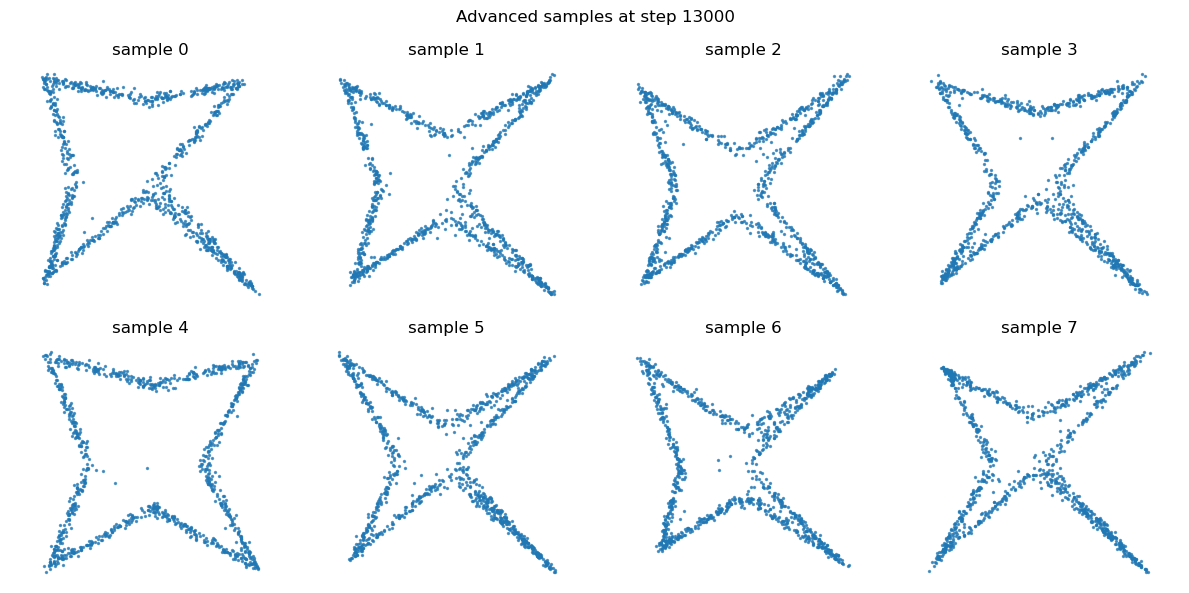

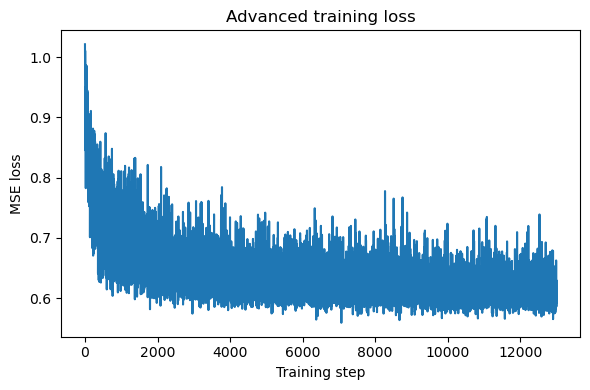

[advanced] step 13100/15000 | loss = 0.617399
[advanced] step 13200/15000 | loss = 0.611729
[advanced] step 13300/15000 | loss = 0.604631
[advanced] step 13400/15000 | loss = 0.626107
[advanced] step 13500/15000 | loss = 0.605863
[advanced] step 13600/15000 | loss = 0.595783
[advanced] step 13700/15000 | loss = 0.611695
[advanced] step 13800/15000 | loss = 0.605904
[advanced] step 13900/15000 | loss = 0.651568
[advanced] step 14000/15000 | loss = 0.645518


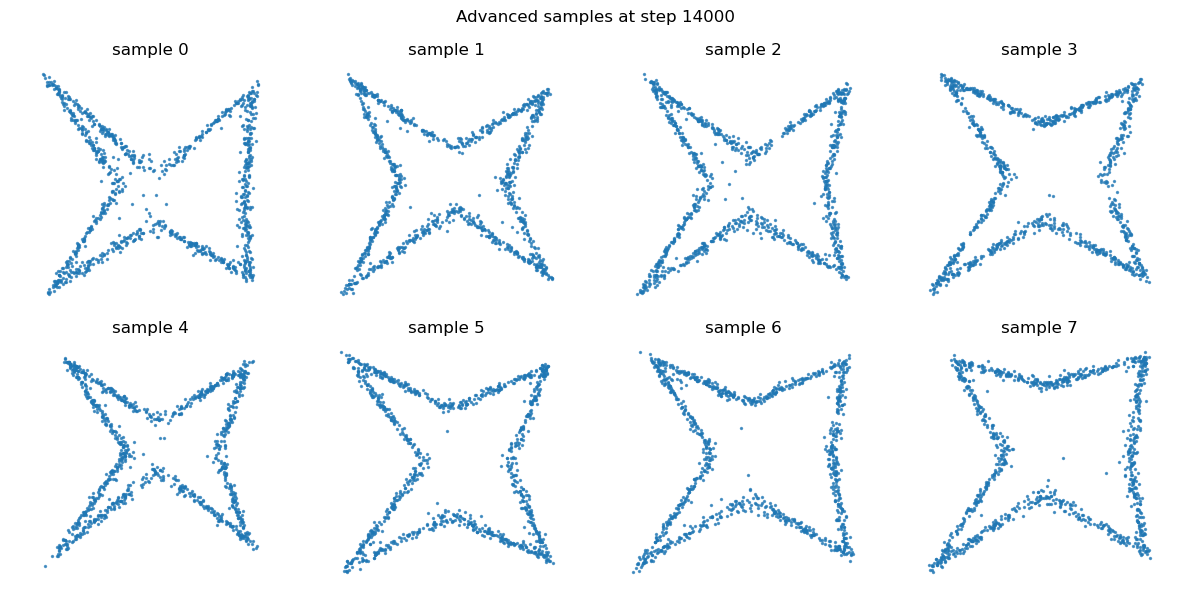

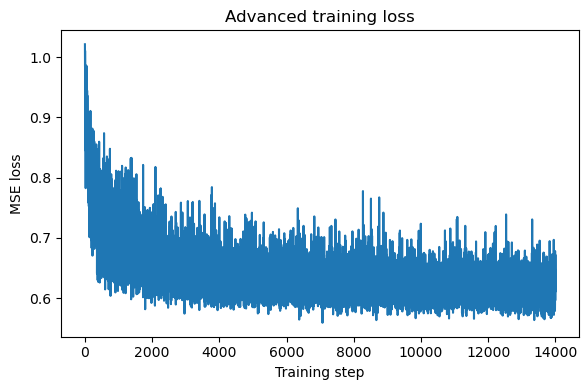

[advanced] step 14100/15000 | loss = 0.587450
[advanced] step 14200/15000 | loss = 0.625743
[advanced] step 14300/15000 | loss = 0.613051
[advanced] step 14400/15000 | loss = 0.664459
[advanced] step 14500/15000 | loss = 0.646352
[advanced] step 14600/15000 | loss = 0.596318
[advanced] step 14700/15000 | loss = 0.590559
[advanced] step 14800/15000 | loss = 0.592474
[advanced] step 14900/15000 | loss = 0.594910
[advanced] step 15000/15000 | loss = 0.602506


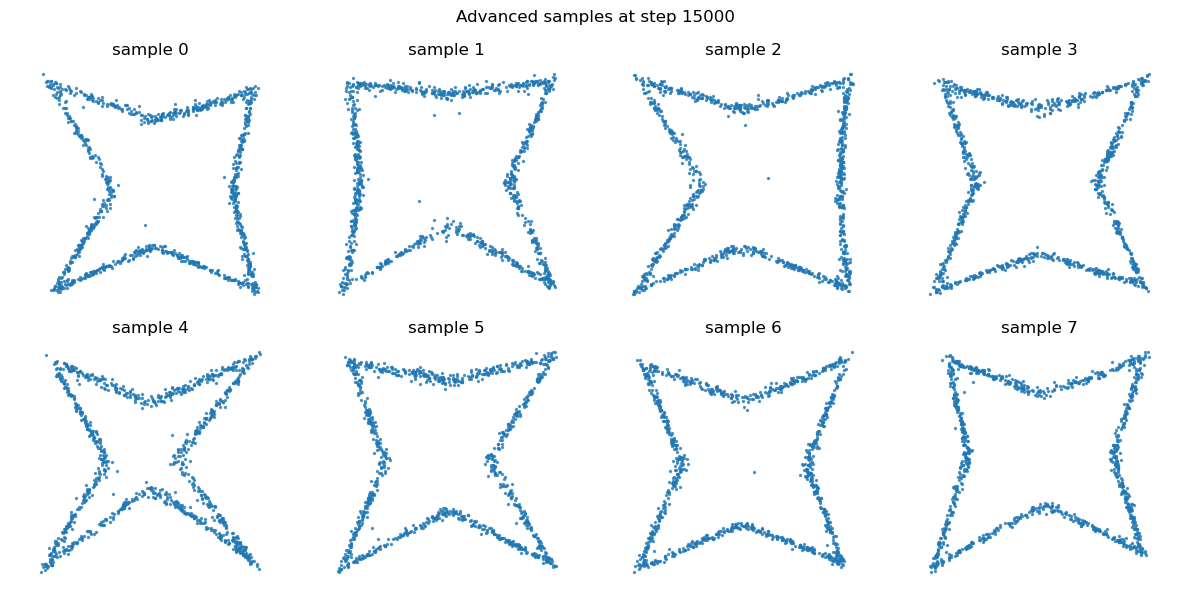

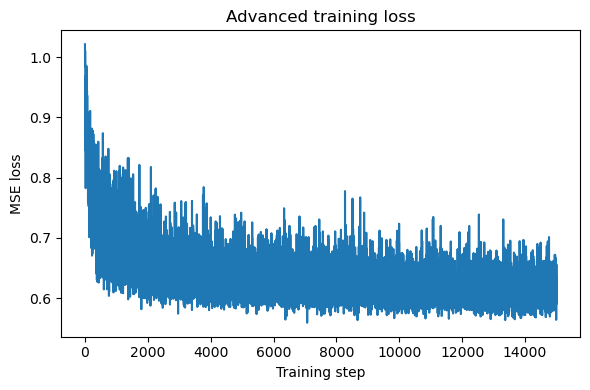

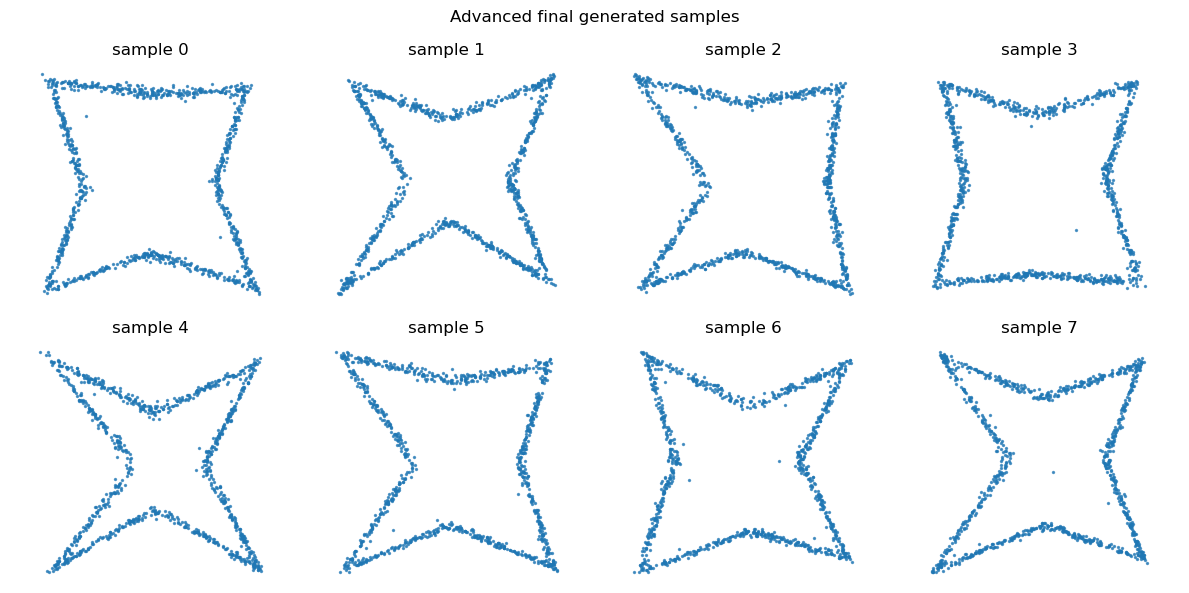

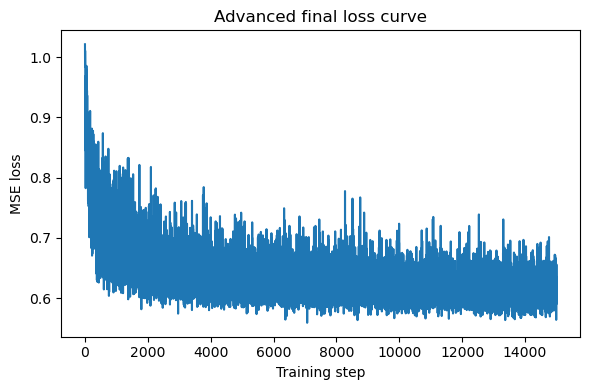

In [14]:
# Train the advanced model

adv_model, adv_diffusion, adv_dataset, adv_losses, adv_final_samples, adv_traj = train_advanced(
    data_path="../data/Advanced/stars_data.npy",
    output_dir="outputs/advanced/stars",
    config=ADV_CONFIG,
    device=device,
)

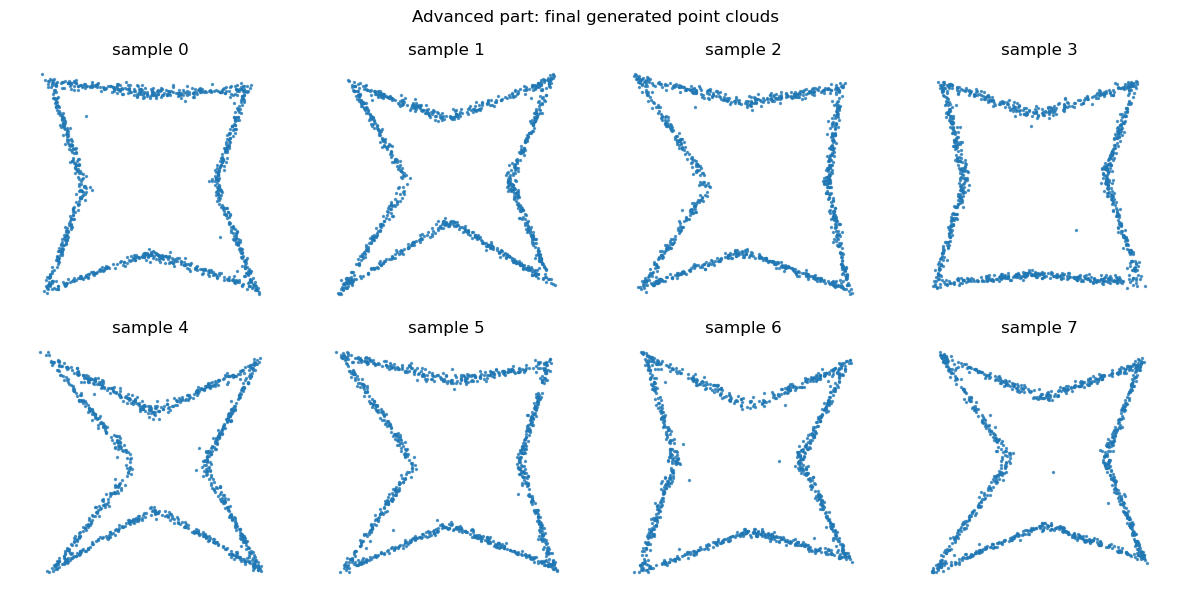

In [15]:
# Final generated samples

plot_pointcloud_grid(
    adv_final_samples,
    title="Advanced part: final generated point clouds",
    ncols=4,
    save_path="outputs/advanced/stars/figures/final_grid_display.png"
)

### Final evaluation

After training, I generate new point clouds from pure Gaussian noise and compare them qualitatively to the training data. I also visualize snapshots of the reverse process to illustrate how structure gradually emerges over the denoising trajectory.

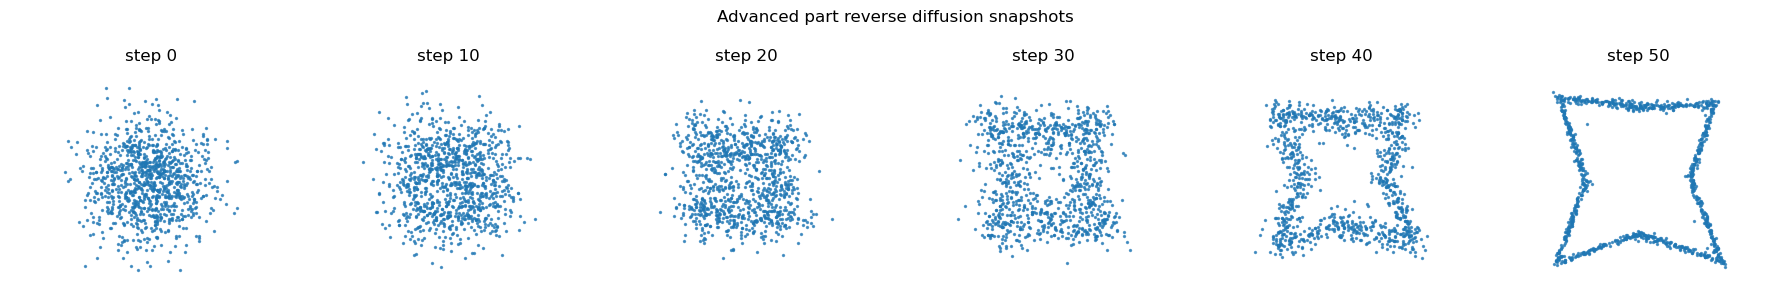

In [16]:
# Reverse trajectory snapshots for one sample

plot_single_cloud_trajectory(
    adv_traj,
    sample_idx=0,
    num_snapshots=6,
    title="Advanced part reverse diffusion snapshots",
    save_path="outputs/advanced/stars/figures/reverse_trajectory_sample0.png"
)

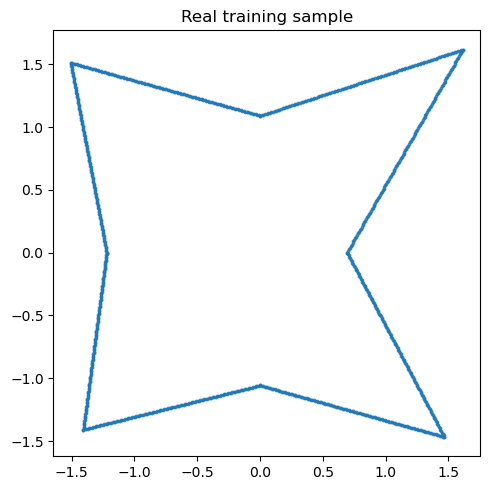

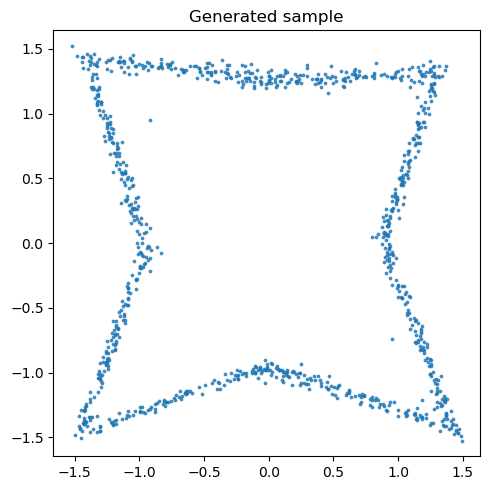

In [17]:
# Optional: visualize a real training sample next to a generated one

real_sample = adv_dataset[0]
generated_sample = adv_final_samples[0]

plot_pointcloud(real_sample, title="Real training sample", save_path="outputs/advanced/stars/figures/real_sample.png")
plot_pointcloud(generated_sample, title="Generated sample", save_path="outputs/advanced/stars/figures/generated_sample.png")

### Discussion

Compared with the mandatory pointwise model, the advanced model has access to global point-cloud context through permutation-invariant pooling. This makes it more suitable for capturing coarse global structure and for reducing artifacts caused by treating all points independently. However, the generated samples may still remain noisy or imperfect, especially if the model capacity is limited or the reverse process has not fully converged.